# Stochastic heat equation

The stochastic heat equation $du = d\,u_{xx}\,dt + g(t)\,dW$ on $(0, 1)$ with homogeneous Dirichlet boundaries, driven by a $Q$-Wiener process. We solve it two ways: an explicit finite-difference scheme in physical space, and the spectral scheme of Section 11, which projects the initial profile onto the sine basis, evolves each mode as an Ornstein–Uhlenbeck process, and transforms back.

In [1]:
import sys
from pathlib import Path

# Locate the project root (the folder containing src/) so the solver modules
# import cleanly and figures are written to figures/.
ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / "src").is_dir():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))
FIGURES = ROOT / "figures"

In [2]:
import math

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib import cm
from mpl_toolkits.mplot3d import axes3d  # noqa: F401  (registers 3d projection)

import heat

A bumpy initial profile $u_0(x) = 5x(x-1)\sin(23x)$ and constant noise scaling $g \equiv 1$, fixed across both solvers.

In [3]:
def u0(x):
    return 5 * x * (x - 1) * math.sin(23 * x)

def g(t):
    return 1.0

rng = np.random.default_rng(67)
K_modes = 50

### Finite-difference solution

The three-point Laplacian stencil with an independent Gaussian increment added at each interior node and step.

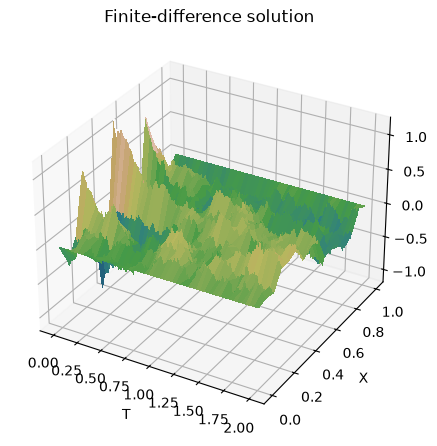

In [4]:
Xf, Yf, uf = heat.heat_fd(u0=u0, T=2.0, Nt=1000, Nx=15, rng=rng, k=0.01, var=0.01)

fig = plt.figure(figsize=(6, 4.5))
ax = fig.add_subplot(projection="3d")
ax.plot_surface(Xf, Yf, uf.T, cmap=cm.gist_earth, linewidth=0, antialiased=False)
ax.set(xlabel="T", ylabel="X", zlabel="H")
ax.set_title("Finite-difference solution")
fig.tight_layout()
plt.show()

### Spectral solution and the role of the covariance

Two driving covariances on the first $K = 50$ modes: the cylindrical case $Q = I$, which excites every sine mode equally, and the trace-class $Q = 10/n^2$, under which the high modes are suppressed so the noise shows up in the smooth, low-frequency components.

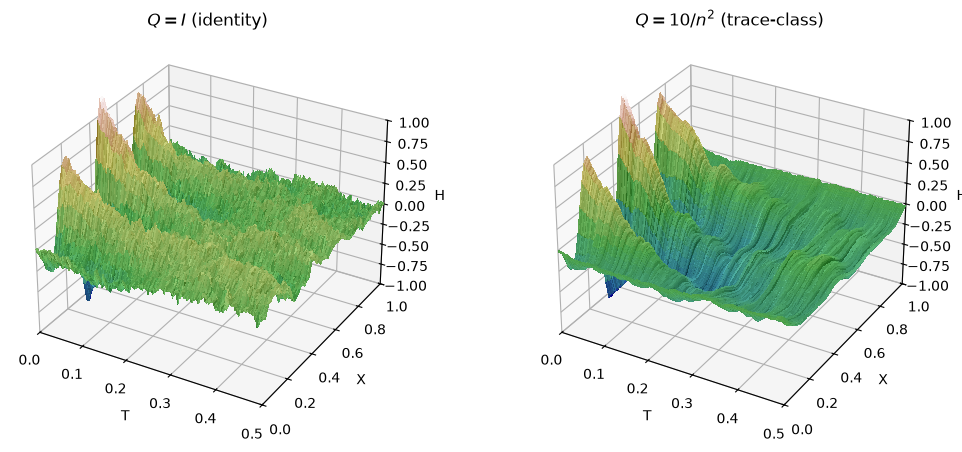

In [5]:
T = 0.5
X1, Y1, u1 = heat.heat_spectral(u0=u0, T=T, Nt=1000, Nx=50, K_modes=K_modes,
                                rng=rng, d=0.01, var=0.5, g=g, Q=np.identity(K_modes))
X2, Y2, u2 = heat.heat_spectral(u0=u0, T=T, Nt=1000, Nx=50, K_modes=K_modes,
                                rng=rng, d=0.01, var=0.5, g=g, Q=heat.trace_class_Q(K_modes))

light = mcolors.LightSource(270, 45)
def shade(u):
    return light.shade(u.T, cmap=cm.gist_earth, vert_exag=0.1, blend_mode="soft")

fig, axs = plt.subplots(ncols=2, subplot_kw=dict(projection="3d"), figsize=(11, 4.5))
panels = [(X1, Y1, u1, r"$Q = I$ (identity)"),
          (X2, Y2, u2, r"$Q = 10/n^2$ (trace-class)")]
for ax, (X, Y, u, title) in zip(axs, panels):
    ax.plot_surface(X, Y, u.T, rstride=1, cstride=1, facecolors=shade(u),
                    linewidth=0, antialiased=False, shade=False)
    ax.set(xlim=(0, T), ylim=(0, 1), zlim=(-1, 1), xlabel="T", ylabel="X", zlabel="H")
    ax.set_title(title)

fig.tight_layout()
fig.savefig(FIGURES / "m2r_heat_equation.png", dpi=120)
plt.show()